# Portfolio Allocation — FIN 3700 Final

**Universe:** PLTR, NVDA, INTC, GLD, EEM (with SPY as benchmark)

**Pipeline:**
1. Setup & data retrieval (Tiingo prices, FRED risk-free rate)
2. Returns & summary statistics (E[r], σ, β, α, HPR)
3. Covariance & correlation matrices
4. Portfolio optimization — GMV and Tangency, both unconstrained and long-only
5. Efficient frontier construction (closed-form for shorts-allowed, iterative for long-only)
6. Visualization — full Markowitz bullet with CAL
7. Final portfolio statistics table

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import cvxpy as cp
from dotenv import load_dotenv
from tiingo import TiingoClient
from fredapi import Fred
from scipy.optimize import minimize  # kept for closed-form-shorts tangency

load_dotenv()

# --- Universe & date range ---
TICKERS = ['SPY', 'PLTR', 'NVDA', 'INTC', 'GLD', 'EEM']
ASSETS  = ['PLTR', 'NVDA', 'INTC', 'GLD', 'EEM']  # portfolio universe (excludes benchmark)

START_DATE = '2020-10-01'  # PLTR IPO; longest workable history for this universe
END_DATE   = '2026-04-01'

TRADING_DAYS = 252

## 2. Data Retrieval

Both blocks are guarded by `if 'var' not in globals()` so re-running the notebook doesn't hammer the APIs.

In [2]:
# --- Risk-free rate from FRED (3-month Treasury) ---
if 'fred_rf' not in globals():
    print("Fetching 3-Month Treasury data via FRED API...")
    fred = Fred(api_key=os.getenv("FRED_API_KEY"))
    fred_series = fred.get_series('DGS3MO',
                                  observation_start=START_DATE,
                                  observation_end=END_DATE)
    fred_rf = pd.DataFrame(fred_series, columns=['DAILY_RF'])
    fred_rf['DAILY_RF'] = fred_rf['DAILY_RF'] / 100 / TRADING_DAYS  # annualized % -> daily decimal
    print("FRED data loaded.")
else:
    print("Using cached FRED data.")

Fetching 3-Month Treasury data via FRED API...
FRED data loaded.


In [3]:
# --- Equity prices from Tiingo ---
if 'prices' not in globals():
    print("Fetching equity data from Tiingo...")
    client = TiingoClient({'session': True, 'api_key': os.getenv("TIINGO_API_KEY")})
    prices = pd.DataFrame()
    for ticker in TICKERS:
        data = client.get_dataframe(ticker, startDate=START_DATE, endDate=END_DATE)
        prices[ticker] = data['adjClose']
        print(f"  Pulled {ticker}")
    prices.index = prices.index.tz_localize(None)
    print("Tiingo data loaded.")
else:
    print("Using cached Tiingo data.")

Fetching equity data from Tiingo...
  Pulled SPY
  Pulled PLTR
  Pulled NVDA
  Pulled INTC
  Pulled GLD
  Pulled EEM
Tiingo data loaded.


In [4]:
# --- Daily simple returns merged with risk-free ---
returns = prices.pct_change().dropna()
returns = returns.join(fred_rf, how='left').ffill().dropna()

print(f"Returns: {len(returns)} trading days from {returns.index[0].date()} to {returns.index[-1].date()}")

Returns: 1380 trading days from 2020-10-02 to 2026-04-01


## 3. Asset-Level Summary Statistics

For each asset: average daily return, daily standard deviation, HPR (from raw prices), CAPM alpha and beta vs SPY.

In [52]:
summary_stats = pd.DataFrame(index=ASSETS)

# --- Daily moments ---
summary_stats['Daily E[r]'] = returns[ASSETS].mean()
summary_stats['Daily σ']    = returns[ASSETS].std()

# --- HPR from raw prices: (P_end / P_start) - 1 ---
summary_stats['HPR'] = (prices[ASSETS].iloc[-1] / prices[ASSETS].iloc[0]) - 1

# --- CAPM regression: r_i - rf = alpha + beta * (r_m - rf) ---
market_excess = (returns['SPY'] - returns['DAILY_RF']).rename('SPY')
X = sm.add_constant(market_excess)

alphas, betas, alpha_tstats = [], [], []
for asset in ASSETS:
    y = returns[asset] - returns['DAILY_RF']
    model = sm.OLS(y, X).fit()
    alphas.append(model.params['const'])
    betas.append(model.params['SPY'])
    alpha_tstats.append(model.tvalues['const'])

summary_stats['Daily α']  = alphas
summary_stats['α t-stat'] = alpha_tstats
summary_stats['β']        = betas

# --- Annualized convenience columns ---
summary_stats['Annual E[r]'] = summary_stats['Daily E[r]'] * TRADING_DAYS
summary_stats['Annual σ']    = summary_stats['Daily σ']   * np.sqrt(TRADING_DAYS)

# Excel-style display
summary_stats.style.format({
    'Daily E[r]':   '{:.4%}',
    'Daily σ':      '{:.4%}',
    'HPR':          '{:,.2%}',
    'Daily α':      '{:.4%}',
    'α t-stat':     '{:.2f}',
    'β':            '{:.3f}',
    'Annual E[r]':  '{:.2%}',
    'Annual σ':     '{:.2%}',
}).background_gradient(cmap='Blues', subset=['Annual E[r]', 'Annual σ', 'HPR'])\
  .background_gradient(cmap='RdYlGn', subset=['α t-stat'], vmin=-3, vmax=3)\
  .set_caption('Asset Summary Statistics  (|t| > 1.96 ≈ 5% significance)')

,Daily E[r],Daily σ,HPR,Daily α,α t-stat,β,Annual E[r],Annual σ
PLTR,0.2940%,4.4236%,"1,448.52%",0.1899%,1.81,1.961,74.09%,70.22%
NVDA,0.2369%,3.2157%,"1,194.93%",0.1271%,2.03,2.083,59.70%,51.05%
INTC,0.0472%,3.0103%,2.45%,-0.0323%,-0.46,1.431,11.88%,47.79%
GLD,0.0712%,1.1120%,145.00%,0.0521%,1.75,0.135,17.93%,17.65%
EEM,0.0344%,1.1726%,46.13%,-0.0132%,-0.57,0.745,8.66%,18.62%


## 4. Covariance & Correlation Matrices

In [6]:
cov_matrix  = returns[ASSETS].cov()
corr_matrix = returns[ASSETS].corr()

# Two displays in one cell — use display() since only the last expression auto-renders
from IPython.display import display

display(corr_matrix.style.format('{:.4f}')
        .background_gradient(cmap='RdBu_r', vmin=-1, vmax=1, axis=None)
        .set_caption('Correlation Matrix'))

display(cov_matrix.style.format('{:.6f}')
        .background_gradient(cmap='Blues', axis=None)
        .set_caption('Covariance Matrix (daily)'))

,PLTR,NVDA,INTC,GLD,EEM
PLTR,1.0000,0.4430,0.2319,0.0683,0.3761
NVDA,0.4430,1.0000,0.3738,0.0808,0.5071
INTC,0.2319,0.3738,1.0000,0.1257,0.4158
GLD,0.0683,0.0808,0.1257,1.0000,0.3118
EEM,0.3761,0.5071,0.4158,0.3118,1.0000


,PLTR,NVDA,INTC,GLD,EEM
PLTR,0.001957,0.000630,0.000309,0.000034,0.000195
NVDA,0.000630,0.001034,0.000362,0.000029,0.000191
INTC,0.000309,0.000362,0.000906,0.000042,0.000147
GLD,0.000034,0.000029,0.000042,0.000124,0.000041
EEM,0.000195,0.000191,0.000147,0.000041,0.000138


## 5. Portfolio Optimization

Two solvers, used twice each (unconstrained vs long-only):
- **GMV** — minimize portfolio variance subject to weights summing to 1
- **Tangency** — maximize Sharpe ratio subject to weights summing to 1

**Bounds:**
- *Unconstrained:* `(-3, 3)` — wide enough that bounds rarely bind, producing a clean frontier
- *Long-only:* `(0, 1)` — classic no-shorting case

In [7]:
# --- Reusable optimization primitives ---
mean_rets = returns[ASSETS].mean()
daily_rf  = returns['DAILY_RF'].mean()
ann_rf    = daily_rf * TRADING_DAYS
n_assets  = len(ASSETS)

# ---------- Closed-form (shorts allowed, no bounds) ----------

def gmv_closed_form(cov):
    """Exact GMV: w = inv(S) 1 / (1' inv(S) 1)."""
    inv = np.linalg.inv(cov.values)
    ones = np.ones(cov.shape[0])
    return (inv @ ones) / (ones @ inv @ ones)

def tangency_closed_form(mu, cov, rf):
    """Exact tangency: w proportional to inv(S) (mu - rf*1), normalized to sum=1."""
    inv = np.linalg.inv(cov.values)
    excess = mu.values - rf
    raw = inv @ excess
    return raw / raw.sum()

def frontier_closed_form(mu, cov, target_returns):
    """Two-fund frontier: w(mu_p) = g + h * mu_p."""
    mu_arr  = mu.values
    cov_arr = cov.values
    n = len(mu_arr)
    ones = np.ones(n)
    inv = np.linalg.inv(cov_arr)
    A = ones @ inv @ ones
    B = ones @ inv @ mu_arr
    C = mu_arr @ inv @ mu_arr
    D = A * C - B**2
    g = (C * (inv @ ones) - B * (inv @ mu_arr)) / D
    h = (A * (inv @ mu_arr) - B * (inv @ ones)) / D
    vols, rets, ws = [], [], []
    for mp in target_returns:
        w = g + h * mp
        vols.append(np.sqrt(w @ cov_arr @ w))
        rets.append(mp)
        ws.append(w)
    return np.array(vols), np.array(rets), np.array(ws)

# ---------- cvxpy (long-only, with bounds) ----------
# These solve real QPs — deterministic, precise, and don't suffer from SLSQP's
# wandering-near-flat-regions problem.

def gmv_cvx(cov, lb=0.0, ub=1.0):
    """Long-only GMV via convex QP."""
    n = cov.shape[0]
    w = cp.Variable(n)
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, cp.psd_wrap(cov.values))),
                      [cp.sum(w) == 1, w >= lb, w <= ub])
    prob.solve()
    return np.array(w.value)

def tangency_cvx(mu, cov, rf, lb=0.0, ub=1.0):
    """
    Long-only tangency via convex QP.
    Trick: maximize Sharpe is non-convex, but the equivalent problem
        minimize w' S w  s.t.  w' (mu - rf*1) = 1, w >= 0
    is convex. Then renormalize so weights sum to 1.
    """
    n = cov.shape[0]
    excess = mu.values - rf
    y = cp.Variable(n)
    prob = cp.Problem(cp.Minimize(cp.quad_form(y, cp.psd_wrap(cov.values))),
                      [excess @ y == 1, y >= lb])
    prob.solve()
    y_val = np.array(y.value)
    return y_val / y_val.sum()

def frontier_cvx(mu, cov, target_returns, lb=0.0, ub=1.0):
    """Long-only frontier sweep via convex QP. Each target return is one QP solve."""
    n = cov.shape[0]
    mu_arr = mu.values
    vols, rets, ws = [], [], []
    for tr in target_returns:
        w = cp.Variable(n)
        prob = cp.Problem(cp.Minimize(cp.quad_form(w, cp.psd_wrap(cov.values))),
                          [cp.sum(w) == 1, mu_arr @ w == tr, w >= lb, w <= ub])
        try:
            prob.solve()
            if w.value is not None and prob.status in ('optimal', 'optimal_inaccurate'):
                w_val = np.array(w.value)
                vols.append(np.sqrt(w_val @ cov.values @ w_val))
                rets.append(tr)
                ws.append(w_val)
        except cp.SolverError:
            continue
    return np.array(vols), np.array(rets), np.array(ws)

In [53]:
# --- Shorts allowed: closed-form everywhere ---
w_gmv_short = gmv_closed_form(cov_matrix)
w_tan_short = tangency_closed_form(mean_rets, cov_matrix, daily_rf)

# --- Long-only: cvxpy QP solves ---
w_gmv_long = gmv_cvx(cov_matrix, lb=0.0, ub=1.0)
w_tan_long = tangency_cvx(mean_rets, cov_matrix, daily_rf, lb=0.0, ub=1.0)

# Sanity check — fail loudly if anything looks degenerate
for label, w in [('GMV shorts', w_gmv_short), ('GMV long', w_gmv_long),
                 ('Tan shorts', w_tan_short), ('Tan long', w_tan_long)]:
    assert abs(w.sum() - 1) < 1e-6, f"{label} weights don't sum to 1 (sum={w.sum():.6f})"

weights_df = pd.DataFrame(
    np.column_stack([w_gmv_short, w_gmv_long, w_tan_short, w_tan_long]),
    index=ASSETS,
    columns=pd.MultiIndex.from_tuples([
        ('σ_min',    'Shorts'),
        ('σ_min',    'No Shorts'),
        ('Tangency', 'Shorts'),
        ('Tangency', 'No Shorts'),
    ])
)

weights_df.style.format('{:.2%}')\
    .background_gradient(cmap='RdBu_r', vmin=-1, vmax=1, axis=None)\
    .set_table_styles([
        # Center the top-level column headers (σ_min, Tangency)
        {'selector': 'th.col_heading.level0', 'props': 'text-align: center;'},
        # Vertical separator between the σ_min group (cols 1-2) and Tangency group (cols 3-4)
        # nth-child counts from 1, and the row-index column is child 1, so data cols start at 2
        {'selector': 'tbody td:nth-child(3)', 'props': 'border-right: 2px solid #555555;'},
        {'selector': 'thead th.col_heading.level1:nth-child(3)',
         'props': 'border-right: 2px solid #555555;'},
        {'selector': 'thead th.col_heading.level0:nth-child(2)',
         'props': 'border-right: 2px solid #555555;'},
    ])\
    .set_caption('Portfolio Weights')

## 6. Efficient Frontier

**Shorts-allowed frontier:** closed-form via the standard two-fund result. Given $\mu$ and $\Sigma$, every minimum-variance portfolio is an affine combination of two reference portfolios, so we can sweep target returns analytically — no solver, no convergence issues, no kinks.

$$ w(\mu_p) = g + h \cdot \mu_p $$

where $g$ and $h$ are derived from $\mathbf{1}^T \Sigma^{-1} \mathbf{1}$, $\mathbf{1}^T \Sigma^{-1} \mu$, and $\mu^T \Sigma^{-1} \mu$.

**Long-only frontier:** iterative — closed form doesn't apply when bounds bind. Warm-started from the previous solution at each grid point.

In [9]:
# (Frontier construction functions are defined in the helpers cell above.)
# - frontier_closed_form  — analytical, shorts allowed (two-fund result)
# - frontier_cvx          — convex QP, long-only with bounds
# Both build curves in the same (vol, return, weights) format.

In [10]:
# --- Shorts-allowed frontier: closed-form sweep, includes dominated half ---
tgt_short = np.linspace(mean_rets.min() * 1.5, mean_rets.max() * 2.0, 100)
front_vol_s, front_ret_s, front_w_s = frontier_closed_form(mean_rets, cov_matrix, tgt_short)

# --- Long-only frontier: cvxpy QP, target range bracketing the GMV ---
# Long-only feasible returns lie strictly within [min(mu), max(mu)].
# Sweep across the full feasible range; the GMV will land inside.
gmv_long_ret = w_gmv_long @ mean_rets.values

# Use a tight epsilon so we don't ask for infeasible boundary returns
eps = 1e-6
tgt_long = np.linspace(mean_rets.min() + eps, mean_rets.max() - eps, 80)

front_vol_l, front_ret_l, front_w_l = frontier_cvx(mean_rets, cov_matrix, tgt_long,
                                                   lb=0.0, ub=1.0)

# Verify the frontier actually reaches down to the GMV
gmv_long_vol = np.sqrt(w_gmv_long @ cov_matrix.values @ w_gmv_long)
print(f"Shorts frontier:   {len(front_ret_s)} pts, vol range [{front_vol_s.min():.4f}, {front_vol_s.max():.4f}]")
print(f"Long-only:         {len(front_ret_l)} pts, vol range [{front_vol_l.min():.4f}, {front_vol_l.max():.4f}]")
print(f"GMV (long) vol:    {gmv_long_vol:.4f}  -- should be ≤ min frontier vol")
assert front_vol_l.min() >= gmv_long_vol - 1e-5, "Long-only frontier missed the GMV!"

Shorts frontier:   100 pts, vol range [0.0092, 0.0579]
Long-only:         80 pts, vol range [0.0092, 0.0442]
GMV (long) vol:    0.0092  -- should be ≤ min frontier vol


## 7. Visualization — Markowitz Bullet with CAL

The full sideways-U includes dominated (lower-half) portfolios drawn dashed; the efficient frontier is solid. The CAL is tangent to the shorts-allowed frontier at the tangency portfolio.

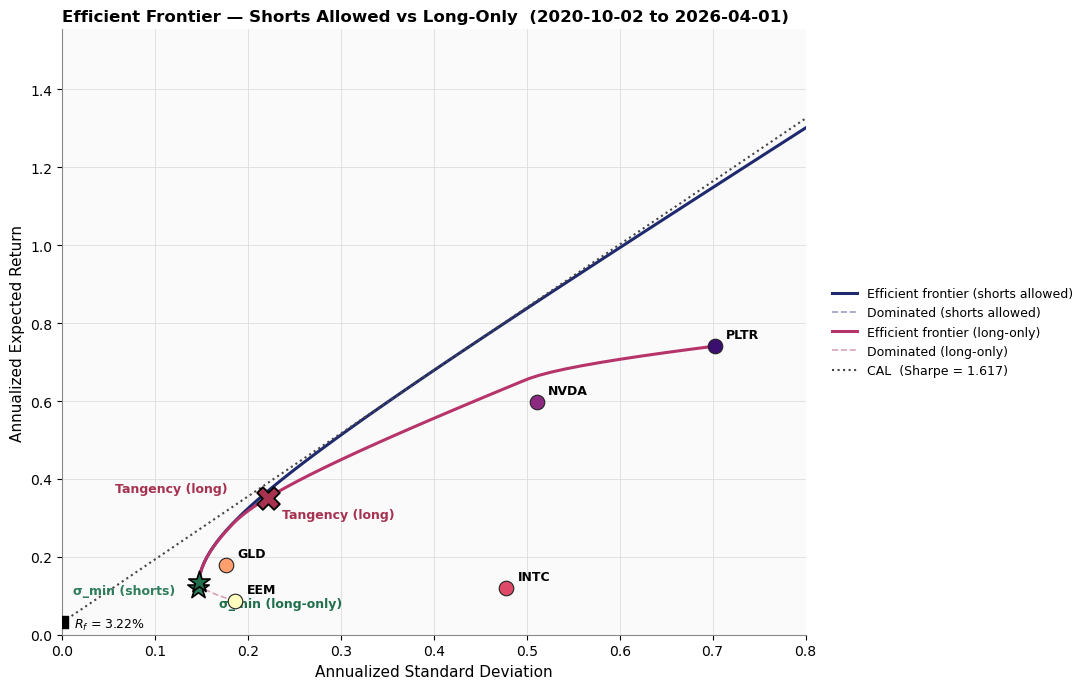

In [11]:
# --- Theming ---
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#FAFAFA',
    'axes.edgecolor':    '#888888',
    'axes.grid':         True,
    'grid.color':        '#DDDDDD',
    'grid.linestyle':    '-',
    'grid.linewidth':    0.6,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         10,
})

# Magma-derived palette (deep purple -> warm gold)
ASSET_COLORS = {
    'PLTR': '#3B0F70',  # deep purple
    'NVDA': '#8C2981',  # magenta
    'INTC': '#DE4968',  # rose
    'GLD':  '#FE9F6D',  # peach
    'EEM':  '#FCFDBF',  # pale gold (will get a dark edge)
}
FRONTIER_SHORTS = '#1F2A6E'  # navy
FRONTIER_LONG   = '#B6346A'  # rose-magenta
TANGENCY_COLOR  = '#E1556C'
GMV_COLOR       = '#2E7D5B'
CAL_COLOR       = '#444444'

def annualize(vols, rets):
    return vols * np.sqrt(TRADING_DAYS), rets * TRADING_DAYS

fv_s, fr_s = annualize(front_vol_s, front_ret_s)
fv_l, fr_l = annualize(front_vol_l, front_ret_l)

def port_stats(w, mu, cov, rf):
    r = w @ mu.values * TRADING_DAYS
    s = np.sqrt(w @ cov.values @ w) * np.sqrt(TRADING_DAYS)
    return r, s, (r - rf) / s

gmv_s_ret, gmv_s_sd, _        = port_stats(w_gmv_short, mean_rets, cov_matrix, ann_rf)
gmv_l_ret, gmv_l_sd, _        = port_stats(w_gmv_long,  mean_rets, cov_matrix, ann_rf)
tan_s_ret, tan_s_sd, tan_s_sh = port_stats(w_tan_short, mean_rets, cov_matrix, ann_rf)
tan_l_ret, tan_l_sd, tan_l_sh = port_stats(w_tan_long,  mean_rets, cov_matrix, ann_rf)

eff_s = fr_s >= gmv_s_ret
eff_l = fr_l >= gmv_l_ret

fig, ax = plt.subplots(figsize=(11, 7))

# --- Frontiers ---
ax.plot(fv_s[eff_s],  fr_s[eff_s],  '-',  color=FRONTIER_SHORTS, lw=2.2, label='Efficient frontier (shorts allowed)')
ax.plot(fv_s[~eff_s], fr_s[~eff_s], '--', color=FRONTIER_SHORTS, lw=1.2, alpha=0.45, label='Dominated (shorts allowed)')
ax.plot(fv_l[eff_l],  fr_l[eff_l],  '-',  color=FRONTIER_LONG,   lw=2.2, label='Efficient frontier (long-only)')
ax.plot(fv_l[~eff_l], fr_l[~eff_l], '--', color=FRONTIER_LONG,   lw=1.2, alpha=0.45, label='Dominated (long-only)')

# --- CAL through shorts-allowed tangency ---
x_max = 0.8
cal_x = np.linspace(0, x_max, 50)
cal_y = ann_rf + tan_s_sh * cal_x
ax.plot(cal_x, cal_y, ':', color=CAL_COLOR, lw=1.5, label=f'CAL  (Sharpe = {tan_s_sh:.3f})')

# --- Individual assets ---
for asset in ASSETS:
    sd = returns[asset].std() * np.sqrt(TRADING_DAYS)
    er = returns[asset].mean() * TRADING_DAYS
    ax.scatter(sd, er, s=110, color=ASSET_COLORS[asset], edgecolors='#222222', lw=0.8, zorder=5)
    ax.annotate(asset, (sd, er), xytext=(8, 6), textcoords='offset points', fontsize=9, fontweight='bold')

# --- GMV / Tangency markers + labels ---
def mark(ax, x, y, marker, color, label, dx=10, dy=10):
    ax.scatter(x, y, marker=marker, s=260, c=color, edgecolors='black', lw=1.2, zorder=6)
    ax.annotate(label, (x, y), xytext=(dx, dy), textcoords='offset points',
                fontsize=9, fontweight='bold', color=color)

mark(ax, gmv_s_sd, gmv_s_ret, '*', GMV_COLOR,      'σ_min (shorts)',      dx=-90, dy=-4)
mark(ax, gmv_l_sd, gmv_l_ret, '*', '#1F6F4A', 'σ_min (long-only)', dx=15, dy=-18)
mark(ax, tan_l_sd, tan_l_ret, 'X', '#A6324F', 'Tangency (long)', dx=10, dy=-15)
mark(ax, tan_l_sd, tan_l_ret, 'X', '#A6324F',      'Tangency (long)',   dx=-110, dy=4)

# Risk-free anchor
ax.scatter(0, ann_rf, marker='s', s=70, c='black', zorder=6)
ax.annotate(f'$R_f$ = {ann_rf:.2%}', (0, ann_rf), xytext=(8, -4), textcoords='offset points', fontsize=9)

ax.set_xlabel('Annualized Standard Deviation', fontsize=11)
ax.set_ylabel('Annualized Expected Return',    fontsize=11)

date_range = f'{returns.index[0].date()} to {returns.index[-1].date()}'
ax.set_title(f'Efficient Frontier — Shorts Allowed vs Long-Only  ({date_range})',
             fontsize=12, fontweight='bold', loc='left')

ax.set_xlim(0, 0.8)
ax.set_ylim(0, ax.get_ylim()[1])

ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0))

# Legend outside, separated from the plot
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

## 8. Final Portfolio Statistics

For each of the four portfolios: E[r], HPR, SD, Beta, Alpha, Jensen's Alpha, Sharpe.

- **Beta / Alpha** come from regressing portfolio excess returns on SPY excess returns (same CAPM specification as the asset-level table).
- **Jensen's Alpha** = realized portfolio excess return − CAPM-predicted excess return = $\bar r_p - r_f - \beta_p (\bar r_m - r_f)$. With shorts allowed, very long horizons of leverage produce sizeable Jensen's alphas — that's a feature of the metric, not a bug.

In [55]:
def portfolio_stat_row(weights, label):
    """Compute the full stat row for a given weight vector."""
    w = np.asarray(weights)

    port_daily = returns[ASSETS] @ w

    er_ann = port_daily.mean() * TRADING_DAYS
    sd_ann = port_daily.std() * np.sqrt(TRADING_DAYS)
    hpr    = (1 + port_daily).prod() - 1

    y = port_daily - returns['DAILY_RF']
    model = sm.OLS(y, X).fit()
    alpha_daily = model.params['const']
    beta_p      = model.params['SPY']

    market_ann = returns['SPY'].mean() * TRADING_DAYS
    jensens    = er_ann - ann_rf - beta_p * (market_ann - ann_rf)
    sharpe     = (er_ann - ann_rf) / sd_ann

    return pd.Series({
        'Annual E[r]': er_ann,
        'Annual σ':    sd_ann,
        'HPR':         hpr,
        'β':           beta_p,
        'Daily α':     alpha_daily,
        "Jensen's α":  jensens,
        'Sharpe':      sharpe,
    }, name=label)

portfolio_stats = pd.concat([
    portfolio_stat_row(w_gmv_short, ('σ_min',    'Shorts')),
    portfolio_stat_row(w_gmv_long,  ('σ_min',    'No Shorts')),
    portfolio_stat_row(w_tan_short, ('Tangency', 'Shorts')),
    portfolio_stat_row(w_tan_long,  ('Tangency', 'No Shorts')),
], axis=1).T

portfolio_stats.index = pd.MultiIndex.from_tuples(
    portfolio_stats.index,
    names=['Portfolio', 'Shorts Allowed?']
)

portfolio_stats.style.format({
    'Annual E[r]': '{:,.2%}',
    'Annual σ':    '{:,.2%}',
    'HPR':         '{:,.2%}',
    'β':           '{:,.3f}',
    'Daily α':     '{:,.4%}',
    "Jensen's α":  '{:,.2%}',
    'Sharpe':      '{:,.4f}',
}).background_gradient(cmap='Greens', subset=['Sharpe'])\
  .background_gradient(cmap='Blues',  subset=['Annual E[r]','HPR'])\
  .set_table_styles([
      # Horizontal separator between σ_min group (rows 1-2) and Tangency group (rows 3-4)
      {'selector': 'tbody tr:nth-of-type(2) td',
       'props': 'border-bottom: 2px solid #555555;'},
      {'selector': 'tbody tr:nth-of-type(2) th',
       'props': 'border-bottom: 2px solid #555555;'},
      # Vertically center the Portfolio-level row labels
      {'selector': 'th.row_heading.level0',
       'props': 'vertical-align: middle;'},
  ])\
  .set_caption('Portfolio Performance Statistics')

In [13]:
# Quick weight sanity — useful when re-running
print("--- σ_min weights ---")
print(f"  Shorts:   {dict(zip(ASSETS, w_gmv_short.round(4)))}")
print(f"  Long:     {dict(zip(ASSETS, w_gmv_long.round(4)))}")
print("--- Tangency weights ---")
print(f"  Shorts:   {dict(zip(ASSETS, w_tan_short.round(4)))}")
print(f"  Long:     {dict(zip(ASSETS, w_tan_long.round(4)))}")

--- σ_min weights ---
  Shorts:   {'PLTR': np.float64(-0.0093), 'NVDA': np.float64(-0.0195), 'INTC': np.float64(-0.0013), 'GLD': np.float64(0.528), 'EEM': np.float64(0.5021)}
  Long:     {'PLTR': np.float64(0.0), 'NVDA': np.float64(0.0), 'INTC': np.float64(0.0), 'GLD': np.float64(0.5385), 'EEM': np.float64(0.4615)}
--- Tangency weights ---
  Shorts:   {'PLTR': np.float64(0.271), 'NVDA': np.float64(0.5644), 'INTC': np.float64(-0.1157), 'GLD': np.float64(1.3378), 'EEM': np.float64(-1.0574)}
  Long:     {'PLTR': np.float64(0.1346), 'NVDA': np.float64(0.2326), 'INTC': np.float64(0.0), 'GLD': np.float64(0.6328), 'EEM': np.float64(-0.0)}


## 9. Security Characteristic Lines & Security Market Line

**SCL** — for each asset, regress excess return on market excess return. The slope is β; the intercept is α. The fitted line is the Security Characteristic Line; the scatter shows how tightly the asset tracks the market.

**SML** — plots E[r] vs β. The line is `r_f + β·(r_m - r_f)` — the CAPM prediction. Assets above the line had positive realized α (outperformed CAPM); below had negative α.

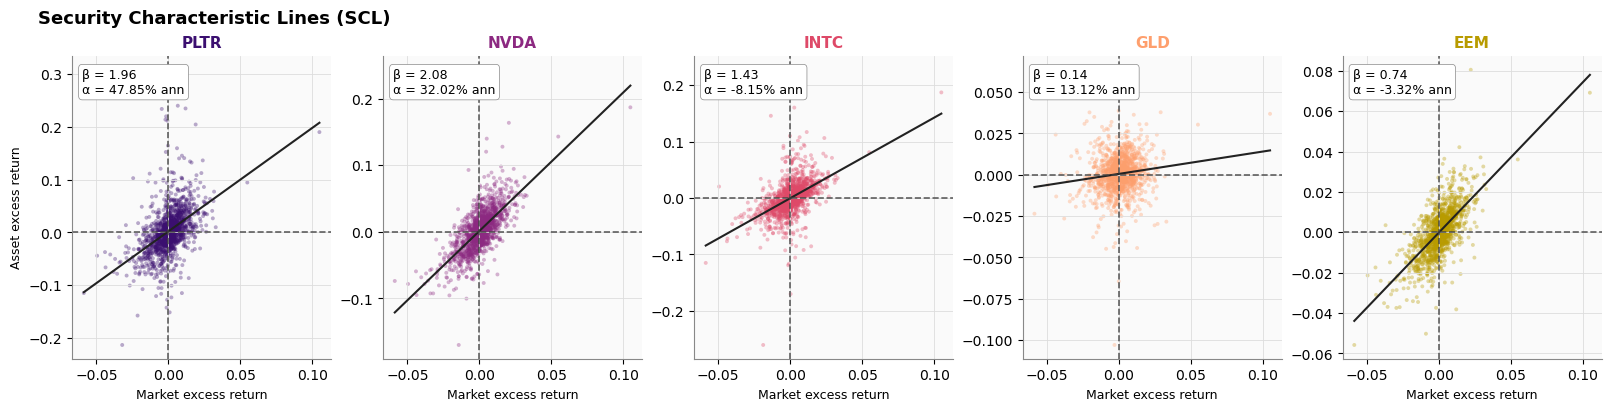

In [14]:
# --- SCL (per asset, small multiples) ---

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#FAFAFA',
    'axes.edgecolor':    '#888888',
    'axes.grid':         True,
    'grid.color':        '#DDDDDD',
    'grid.linestyle':    '-',
    'grid.linewidth':    0.6,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         10,
})

ASSET_COLORS = {
    'PLTR': '#3B0F70',
    'NVDA': '#8C2981',
    'INTC': '#DE4968',
    'GLD':  '#FE9F6D',
    'EEM':  '#B89B00',
}

market_x = (returns['SPY'] - returns['DAILY_RF']).values

fig_scl, axes = plt.subplots(1, 5, figsize=(16, 4), constrained_layout=True)

asset_alphas, asset_betas = {}, {}
for j, asset in enumerate(ASSETS):
    ax = axes[j]
    y = (returns[asset] - returns['DAILY_RF']).values
    
    X_fit = sm.add_constant(market_x)
    res = sm.OLS(y, X_fit).fit()
    alpha_d = res.params[0]
    beta    = res.params[1]
    asset_alphas[asset] = alpha_d
    asset_betas[asset]  = beta
    
    ax.scatter(market_x, y, s=8, alpha=0.35, color=ASSET_COLORS[asset], edgecolors='none')
    xx = np.linspace(market_x.min(), market_x.max(), 50)
    ax.plot(xx, alpha_d + beta * xx, '-', color='#222222', lw=1.5)
    
    # Heavy dashed origin axes — clearly mark x=0 and y=0
    ax.axhline(0, color='#444444', lw=1.2, linestyle='--', zorder=2, alpha=0.85)
    ax.axvline(0, color='#444444', lw=1.2, linestyle='--', zorder=2, alpha=0.85)
    
    ax.set_title(asset, fontsize=11, fontweight='bold', color=ASSET_COLORS[asset])
    ax.set_xlabel('Market excess return', fontsize=9)
    if j == 0:
        ax.set_ylabel('Asset excess return', fontsize=9)
    
    ax.text(0.04, 0.96, f'β = {beta:.2f}\nα = {alpha_d*TRADING_DAYS:.2%} ann',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#888888', lw=0.5))

fig_scl.suptitle('Security Characteristic Lines (SCL)', fontsize=13, fontweight='bold', x=0.02, ha='left')
plt.show()

### Security Market Line

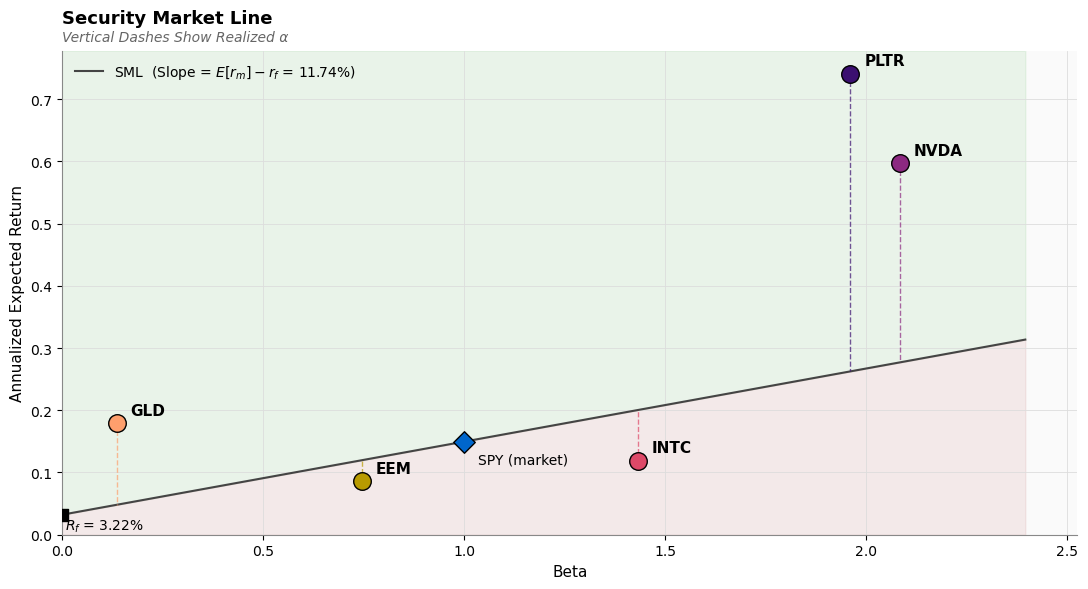

In [15]:
# --- SML (separate figure) ---

fig_sml, ax_sml = plt.subplots(figsize=(11, 6))

market_ann = returns['SPY'].mean() * TRADING_DAYS
beta_grid = np.linspace(-0.2, max(asset_betas.values()) * 1.15, 50)
sml_y = ann_rf + beta_grid * (market_ann - ann_rf)
ax_sml.plot(beta_grid, sml_y, '-', color='#444444', lw=1.5,
            label=f'SML  (Slope = $E[r_m] - r_f$ = {market_ann - ann_rf:.2%})')

for asset in ASSETS:
    b = asset_betas[asset]
    er = returns[asset].mean() * TRADING_DAYS
    ax_sml.scatter(b, er, s=160, color=ASSET_COLORS[asset], edgecolors='black', lw=1, zorder=5)
    
    pred = ann_rf + b * (market_ann - ann_rf)
    ax_sml.plot([b, b], [er, pred], '--', color=ASSET_COLORS[asset], lw=1.0, alpha=0.7)
    
    ax_sml.annotate(asset, (b, er), xytext=(10, 6), textcoords='offset points',
                    fontsize=11, fontweight='bold')

ax_sml.scatter(1.0, market_ann, marker='D', s=120, color='#0066CC', edgecolors='black', zorder=5)
ax_sml.annotate('SPY (market)', (1.0, market_ann), xytext=(10, -16), textcoords='offset points', fontsize=10)
ax_sml.scatter(0, ann_rf, marker='s', s=80, color='black', zorder=5)
ax_sml.annotate(f'$R_f$ = {ann_rf:.2%}', (0, ann_rf), xytext=(2, -11), textcoords='offset points', fontsize=10)

ax_sml.set_xlabel('Beta', fontsize=11)
ax_sml.set_ylabel('Annualized Expected Return', fontsize=11)
ax_sml.set_title('Security Market Line', fontsize=13, fontweight='bold', loc='left', pad=20)
ax_sml.text(0.0, 1.02, 'Vertical Dashes Show Realized α', transform=ax_sml.transAxes,
            fontsize=10, style='italic', color='#666666')
ax_sml.legend(loc='upper left', fontsize=10, frameon=False)
ax_sml.set_xlim(left=0)
ax_sml.set_ylim(bottom=0)
ax_sml.margins(x=0, y=0)

ax_sml.fill_between(beta_grid, sml_y, ax_sml.get_ylim()[1], color='#88CC88', alpha=0.15, zorder=0)
ax_sml.fill_between(beta_grid, sml_y, 0, color='#CC8888', alpha=0.15, zorder=0)


plt.tight_layout()
plt.show()

## 10. Cumulative Wealth

$1 invested at the start of the sample, compounded daily through to the end. Shows the realized growth path of each asset and each portfolio.

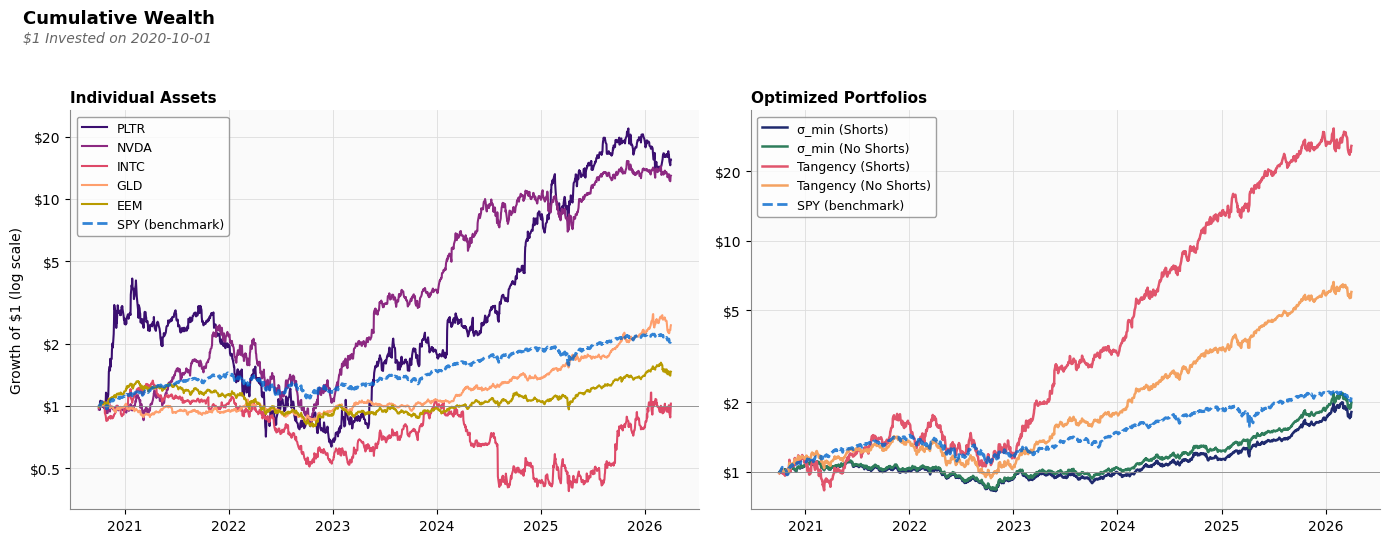

,
PLTR,$15.49
NVDA,$12.95
INTC,$1.02
GLD,$2.45
EEM,$1.46
σ_min (Shorts),$1.81
σ_min (No Shorts),$1.99
Tangency (Shorts),$25.80
Tangency (No Shorts),$6.01
SPY,$2.10


In [58]:
# --- Cumulative wealth: $1 invested at start, compounded daily ---

import matplotlib.ticker as mticker

# Asset cumulative wealth
asset_cumwealth = (1 + returns[ASSETS]).cumprod()

# Portfolio cumulative wealth (assumes daily rebalancing back to target weights)
def portfolio_cumwealth(weights):
    daily = returns[ASSETS] @ weights
    return (1 + daily).cumprod()

port_cumwealth = pd.DataFrame({
    'σ_min (Shorts)':       portfolio_cumwealth(w_gmv_short),
    'σ_min (No Shorts)':    portfolio_cumwealth(w_gmv_long),
    'Tangency (Shorts)':    portfolio_cumwealth(w_tan_short),
    'Tangency (No Shorts)': portfolio_cumwealth(w_tan_long),
})

# Also include SPY for benchmark context
spy_cumwealth = (1 + returns['SPY']).cumprod()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)

# --- Left: assets vs SPY ---
for asset in ASSETS:
    ax1.plot(asset_cumwealth.index, asset_cumwealth[asset],
             label=asset, color=ASSET_COLORS[asset], lw=1.5)
ax1.plot(spy_cumwealth.index, spy_cumwealth, label='SPY (benchmark)',
         color='#0066CC', lw=2, linestyle='--', alpha=0.8)
ax1.axhline(1, color='#888888', lw=0.6)
ax1.set_yscale('log')
ax1.set_title('Individual Assets', fontsize=11, fontweight='bold', loc='left')
ax1.set_ylabel('Growth of $1 (log scale)', fontsize=10)
ax1.legend(loc='upper left', fontsize=9, frameon=True, edgecolor='#888888', facecolor='white')



# --- Right: portfolios vs SPY ---
PORT_COLORS = {
    'σ_min (Shorts)':       '#1F2A6E',
    'σ_min (No Shorts)':    '#2E7D5B',
    'Tangency (Shorts)':    '#E1556C',
    'Tangency (No Shorts)': '#F4A261',
}
for col in port_cumwealth.columns:
    ax2.plot(port_cumwealth.index, port_cumwealth[col],
             label=col, color=PORT_COLORS[col], lw=1.8)
ax2.plot(spy_cumwealth.index, spy_cumwealth, label='SPY (benchmark)',
         color='#0066CC', lw=2, linestyle='--', alpha=0.8)
ax2.axhline(1, color='#888888', lw=0.6)
ax2.set_yscale('log')
ax2.set_title('Optimized Portfolios', fontsize=11, fontweight='bold', loc='left')
ax2.legend(loc='upper left', fontsize=9, frameon=True, edgecolor='#888888', facecolor='white')

fig.suptitle('Cumulative Wealth', fontsize=13, fontweight='bold', x=0.02, ha='left', y=0.98)
fig.text(0.02, 0.92, f'$1 Invested on {START_DATE}', fontsize=10, style='italic', color='#666666')

for ax in [ax1, ax2]:
    ax.yaxis.set_major_locator(mticker.FixedLocator([0.5, 1, 2, 5, 10, 20, 50]))
    ax.yaxis.set_minor_locator(mticker.NullLocator())  # hide intermediate log ticks
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:g}'))

plt.tight_layout(rect=[0, 0, 1, 0.92])  # reserve top 8% of figure for title/subtitle
plt.show()

# Print final wealth values for the table
final_wealth = pd.DataFrame({
    '':  pd.concat([asset_cumwealth.iloc[-1], port_cumwealth.iloc[-1],
                           pd.Series({'SPY': spy_cumwealth.iloc[-1]})])
})
final_wealth.style.format('${:.2f}').background_gradient(cmap='Greens')\
    .set_caption('Cumulative Wealth')

## 11. Efficient Frontier Composition

As the target return increases along the efficient frontier, the optimal weights shift. These stacked-area charts show exactly which assets enter and exit the optimal portfolio at each point.

### Long-Only Composition

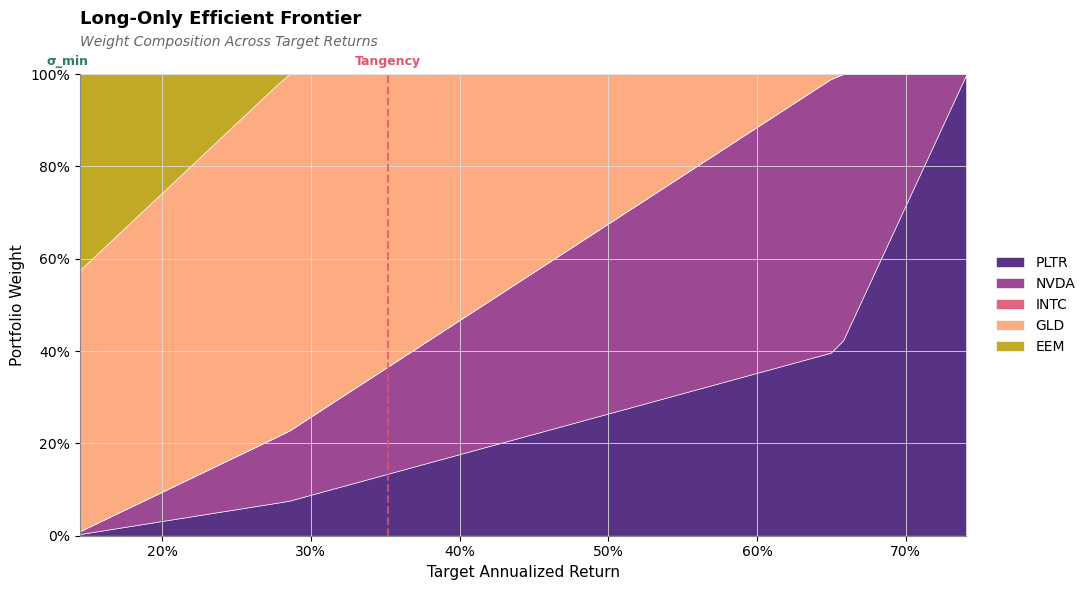

In [17]:
# --- Long-only frontier composition: weights vs target return ---

# Restrict to the efficient half (target return >= GMV return)
eff_mask = front_ret_l >= gmv_long_ret
eff_rets = front_ret_l[eff_mask] * TRADING_DAYS  # annualized x-axis
eff_ws   = front_w_l[eff_mask]                    # (n_points, n_assets)

# Sort by target return ascending
sort_idx = np.argsort(eff_rets)
eff_rets = eff_rets[sort_idx]
eff_ws   = eff_ws[sort_idx]

fig, ax = plt.subplots(figsize=(11, 6))

# Stacked area
colors = [ASSET_COLORS[a] for a in ASSETS]
ax.stackplot(eff_rets, eff_ws.T, labels=ASSETS, colors=colors, alpha=0.85, edgecolor='white', lw=0.5)

# Mark GMV and Tangency target returns
gmv_x = gmv_long_ret * TRADING_DAYS
tan_x = (w_tan_long @ mean_rets.values) * TRADING_DAYS
ax.axvline(gmv_x, color='#2E7D5B', lw=1.5, linestyle='--', alpha=0.8)
ax.text(gmv_x, 1.02, 'σ_min', color='#2E7D5B', fontsize=9, fontweight='bold', ha='center', transform=ax.get_xaxis_transform())
ax.axvline(tan_x, color='#E1556C', lw=1.5, linestyle='--', alpha=0.8)
ax.text(tan_x, 1.02, 'Tangency', color='#E1556C', fontsize=9, fontweight='bold', ha='center', transform=ax.get_xaxis_transform())

ax.set_xlim(eff_rets.min(), eff_rets.max())
ax.set_ylim(0, 1)
ax.set_xlabel('Target Annualized Return', fontsize=11)
ax.set_ylabel('Portfolio Weight', fontsize=11)
ax.set_title('Long-Only Efficient Frontier', fontsize=13, fontweight='bold', loc='left', pad=36)
ax.text(0.0, 1.06, 'Weight Composition Across Target Returns', transform=ax.transAxes,
        fontsize=10, style='italic', color='#666666')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, frameon=False)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

### Shorts-Allowed Composition

Same view but for the shorts-allowed frontier. Negative weights stack downward from zero, positive weights upward — so the visible vertical extent shows the total leverage at each target return. The dashed line at 100% marks the long-side total; whatever crosses below zero is shorted.

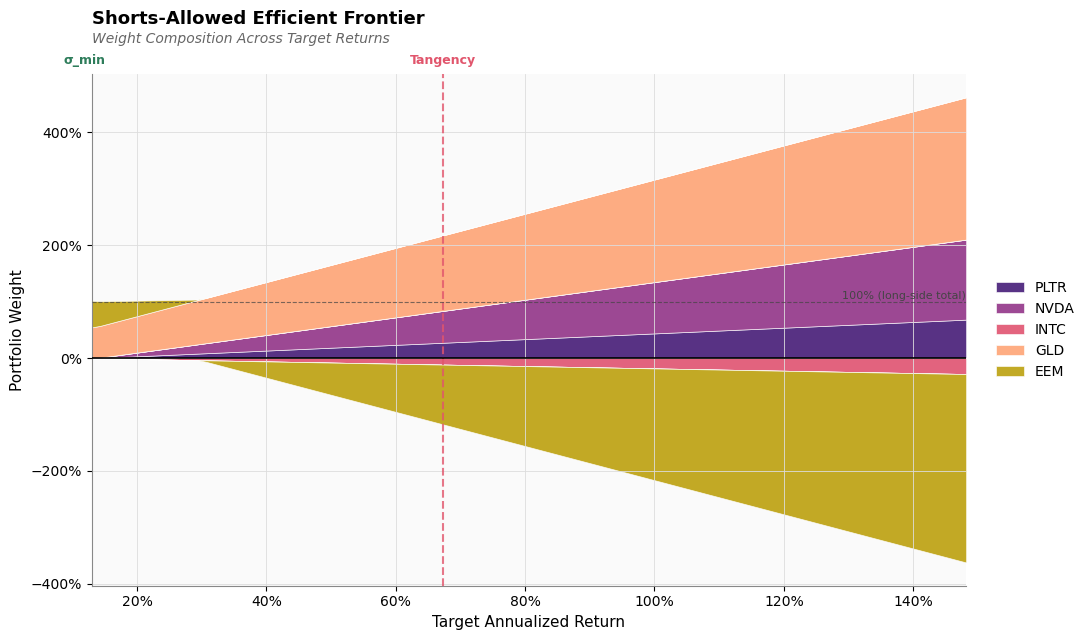

In [18]:
# --- Shorts-allowed frontier composition: weights vs target return ---
# stackplot can't handle mixed signs natively — we stack positives upward
# from 0 and negatives downward from 0.

gmv_short_ret = w_gmv_short @ mean_rets.values
eff_mask_s = front_ret_s >= gmv_short_ret
eff_rets_s = front_ret_s[eff_mask_s] * TRADING_DAYS
eff_ws_s   = front_w_s[eff_mask_s]

sort_idx = np.argsort(eff_rets_s)
eff_rets_s = eff_rets_s[sort_idx]
eff_ws_s   = eff_ws_s[sort_idx]

fig, ax = plt.subplots(figsize=(11, 6.5))

# Split each asset's weights into positive and negative parts
pos_parts = np.where(eff_ws_s > 0, eff_ws_s, 0)
neg_parts = np.where(eff_ws_s < 0, eff_ws_s, 0)

colors = [ASSET_COLORS[a] for a in ASSETS]

# Stack positives upward (with labels for the legend)
ax.stackplot(eff_rets_s, pos_parts.T, labels=ASSETS, colors=colors,
             alpha=0.85, edgecolor='white', lw=0.5)

# Stack negatives downward (no labels — dedupe via legend)
ax.stackplot(eff_rets_s, neg_parts.T, colors=colors,
             alpha=0.85, edgecolor='white', lw=0.5)

# Reference lines
ax.axhline(0, color='black', lw=1.2, zorder=4)
ax.axhline(1, color='#444444', lw=0.8, linestyle='--', zorder=4, alpha=0.7)
ax.text(eff_rets_s.max(), 1.005, '100% (long-side total)',
        ha='right', va='bottom', fontsize=8, color='#444444')

# Mark GMV and Tangency target returns
gmv_x_s = gmv_short_ret * TRADING_DAYS
tan_x_s = (w_tan_short @ mean_rets.values) * TRADING_DAYS
ax.axvline(gmv_x_s, color='#2E7D5B', lw=1.5, linestyle='--', alpha=0.8)
ax.text(gmv_x_s, 1.02, 'σ_min', color='#2E7D5B', fontsize=9, fontweight='bold',
        ha='center', transform=ax.get_xaxis_transform())
ax.axvline(tan_x_s, color='#E1556C', lw=1.5, linestyle='--', alpha=0.8)
ax.text(tan_x_s, 1.02, 'Tangency', color='#E1556C', fontsize=9, fontweight='bold',
        ha='center', transform=ax.get_xaxis_transform())

ax.set_xlim(eff_rets_s.min(), eff_rets_s.max())
ax.set_xlabel('Target Annualized Return', fontsize=11)
ax.set_ylabel('Portfolio Weight', fontsize=11)
ax.set_title('Shorts-Allowed Efficient Frontier', fontsize=13, fontweight='bold', loc='left', pad=36)
ax.text(0.0, 1.06, 'Weight Composition Across Target Returns', transform=ax.transAxes,
        fontsize=10, style='italic', color='#666666')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, frameon=False)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

## 12. Out-of-Sample Performance & Regime Comparison

The portfolios above are optimized using the *full* sample. That makes them look great — by construction, the tangency portfolio achieves the highest Sharpe **on the data that was used to find it**. The real test is what happens when you commit to those weights, then live through whatever the market does next.

This section splits the data into two windows:

- **Estimation window** — all data except the last 12 months. Used to compute means, covariances, correlations, and to find the optimal weights.
- **Evaluation window** — the most recent 12 months. The estimation-window weights are applied here without re-optimization.

Two outputs:

1. **Side-by-side correlation/covariance matrices** for the two windows. Look at how the off-diagonals shift between regimes — a large change is the empirical evidence that "diversification benefits are unstable."
2. **In-sample vs. out-of-sample portfolio statistics** — the same Sharpe/return/drawdown numbers, computed first on the estimation window (where the optimizer was looking) and then on the evaluation window (where it had to pay up).

In [19]:
# --- Split returns into estimation and evaluation windows ---

split_date = returns.index[-1] - pd.DateOffset(months=12)

returns_est  = returns.loc[:split_date].copy()
returns_eval = returns.loc[split_date:].iloc[1:].copy()  # skip the split day to avoid double-counting

print(f"Estimation window:  {returns_est.index[0].date()}  to  {returns_est.index[-1].date()}  ({len(returns_est)} days)")
print(f"Evaluation window:  {returns_eval.index[0].date()}  to  {returns_eval.index[-1].date()}  ({len(returns_eval)} days)")

Estimation window:  2020-10-02  to  2025-04-01  (1129 days)
Evaluation window:  2025-04-02  to  2026-04-01  (251 days)


In [60]:
# --- Correlation matrices in each window ---
from IPython.display import display

corr_est  = returns_est[ASSETS].corr()
corr_eval = returns_eval[ASSETS].corr()
corr_diff = corr_eval - corr_est

est_range  = f'{returns_est.index[0].date()} to {returns_est.index[-1].date()}'
eval_range = f'{returns_eval.index[0].date()} to {returns_eval.index[-1].date()}'

def two_line_caption(title, subtitle):
    return (f'<div style="font-weight: bold; font-size: 1.0em;">{title}</div>'
            f'<div style="font-style: italic; font-size: 0.85em; color: #666;">{subtitle}</div>')

display(corr_est.style.format('{:.4f}')
        .background_gradient(cmap='RdBu_r', vmin=-1, vmax=1, axis=None)
        .set_caption(two_line_caption('Correlation Matrix', f'Estimation Window: {est_range}')))

display(corr_eval.style.format('{:.4f}')
        .background_gradient(cmap='RdBu_r', vmin=-1, vmax=1, axis=None)
        .set_caption(two_line_caption('Correlation Matrix', f'Evaluation Window: {eval_range}')))

display(corr_diff.style.format('{:+.4f}')
        .background_gradient(cmap='RdBu_r', vmin=-0.5, vmax=0.5, axis=None)
        .set_caption(two_line_caption('Correlation Shift', 'Evaluation − Estimation')))

,PLTR,NVDA,INTC,GLD,EEM
PLTR,1.0000,0.4275,0.2346,0.0680,0.3688
NVDA,0.4275,1.0000,0.3907,0.1014,0.4980
INTC,0.2346,0.3907,1.0000,0.1433,0.4085
GLD,0.0680,0.1014,0.1433,1.0000,0.3001
EEM,0.3688,0.4980,0.4085,0.3001,1.0000


,PLTR,NVDA,INTC,GLD,EEM
PLTR,1.0000,0.5553,0.2682,0.0904,0.4332
NVDA,0.5553,1.0000,0.3892,0.0457,0.5836
INTC,0.2682,0.3892,1.0000,0.0955,0.4490
GLD,0.0904,0.0457,0.0955,1.0000,0.3652
EEM,0.4332,0.5836,0.4490,0.3652,1.0000


,PLTR,NVDA,INTC,GLD,EEM
PLTR,+0.0000,+0.1277,+0.0336,+0.0224,+0.0644
NVDA,+0.1277,+0.0000,-0.0015,-0.0557,+0.0856
INTC,+0.0336,-0.0015,+0.0000,-0.0478,+0.0405
GLD,+0.0224,-0.0557,-0.0478,+0.0000,+0.0651
EEM,+0.0644,+0.0856,+0.0405,+0.0651,+0.0000


In [62]:
# --- Re-estimate optimal portfolios using ONLY the estimation window ---

mean_rets_est = returns_est[ASSETS].mean()
cov_matrix_est = returns_est[ASSETS].cov()
daily_rf_est = returns_est['DAILY_RF'].mean()

# σ_min portfolios
w_gmv_short_est = gmv_closed_form(cov_matrix_est)
w_gmv_long_est  = gmv_cvx(cov_matrix_est, lb=0.0, ub=1.0)

# Tangency portfolios
w_tan_short_est = tangency_closed_form(mean_rets_est, cov_matrix_est, daily_rf_est)
w_tan_long_est  = tangency_cvx(mean_rets_est, cov_matrix_est, daily_rf_est, lb=0.0, ub=1.0)

est_weights = pd.DataFrame(
    np.column_stack([w_gmv_short_est, w_gmv_long_est, w_tan_short_est, w_tan_long_est]),
    index=ASSETS,
    columns=pd.MultiIndex.from_tuples([
        ('σ_min',    'Shorts'),
        ('σ_min',    'No Shorts'),
        ('Tangency', 'Shorts'),
        ('Tangency', 'No Shorts'),
    ])
)

est_weights.style.format('{:.2%}')\
    .background_gradient(cmap='RdBu_r', vmin=-1, vmax=1, axis=None)\
    .set_table_styles([
        # Center the top-level column headers (σ_min, Tangency)
        {'selector': 'th.col_heading.level0', 'props': 'text-align: center;'},
        # Vertical separator between σ_min group and Tangency group
        {'selector': 'tbody td:nth-child(3)',
         'props': 'border-right: 2px solid #555555;'},
        {'selector': 'thead th.col_heading.level1:nth-child(3)',
         'props': 'border-right: 2px solid #555555;'},
        {'selector': 'thead th.col_heading.level0:nth-child(2)',
         'props': 'border-right: 2px solid #555555;'},
    ])\
    .set_caption('Portfolio Weights Estimated on Estimation Window Only')

In [76]:
# --- Compute portfolio statistics IN-SAMPLE and OUT-OF-SAMPLE ---
# Same weights (estimated on est window) applied to both windows.

def stats_for_window(weights, ret_window, label):
    """Compute key statistics applying given weights to a specific return window."""
    w = np.asarray(weights)
    port_daily = ret_window[ASSETS] @ w
    rf_window  = ret_window['DAILY_RF'].mean()

    er_ann  = port_daily.mean() * TRADING_DAYS
    sd_ann  = port_daily.std()  * np.sqrt(TRADING_DAYS)
    rf_ann  = rf_window * TRADING_DAYS
    sharpe  = (er_ann - rf_ann) / sd_ann

    cum = (1 + port_daily).cumprod()
    hpr = cum.iloc[-1] - 1
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    max_dd = drawdown.min()

    return pd.Series({
        'Annual E[r]': er_ann,
        'Annual σ':    sd_ann,
        'Sharpe':      sharpe,
        'HPR':         hpr,
        'Max DD':      max_dd,
    }, name=label)

portfolios = [
    ('σ_min',    'Shorts',    w_gmv_short_est),
    ('σ_min',    'No Shorts', w_gmv_long_est),
    ('Tangency', 'Shorts',    w_tan_short_est),
    ('Tangency', 'No Shorts', w_tan_long_est),
]

oos_rows = []
for port_name, short_status, w in portfolios:
    oos_rows.append(stats_for_window(w, returns_est,  (port_name, short_status, 'Estimation')))
    oos_rows.append(stats_for_window(w, returns_eval, (port_name, short_status, 'Evaluation')))

oos_table = pd.concat(oos_rows, axis=1).T
oos_table.index = pd.MultiIndex.from_tuples(
    oos_table.index,
    names=['Portfolio', 'Shorts Allowed?', 'Sample']
)

caption_html = (
    '<div style="font-weight: bold; font-size: 1.05em; color: #222; text-align: left;">'
    'Portfolio Performance'
    '</div>'
    '<div style="font-style: italic; font-size: 0.85em; color: #666; font-weight: normal; text-align: left;">'
    'In-Sample (Estimation) vs Out-of-Sample (Evaluation)'
    '</div>'
)

# Pre-mixed colors for nested shading
# σ_min: blue family — darker on "Shorts" rows, lighter on "No Shorts" rows
SIGMIN_DARK  = '#D8DEE8'   # Shorts rows (1, 2)
SIGMIN_LIGHT = '#E8ECF2'   # No Shorts rows (3, 4)
# Tangency: tan family — same pattern
TAN_DARK     = '#E8DDC8'   # Shorts rows (5, 6)
TAN_LIGHT    = '#F1EAD9'   # No Shorts rows (7, 8)

oos_table.style.format({
    'Annual E[r]': '{:,.2%}',
    'Annual σ':    '{:,.2%}',
    'Sharpe':      '{:,.4f}',
    'HPR':         '{:,.2%}',
    'Max DD':      '{:,.2%}',
}).background_gradient(cmap='RdYlGn',   subset=['Sharpe'])\
  .background_gradient(cmap='RdYlGn_r', subset=['Max DD'])\
  .set_table_styles([
      # === Row shading — darker for "Shorts" pair, lighter for "No Shorts" pair ===
      {'selector': 'tbody tr:nth-of-type(1), tbody tr:nth-of-type(2)',
       'props': f'background-color: {SIGMIN_DARK};'},
      {'selector': 'tbody tr:nth-of-type(3), tbody tr:nth-of-type(4)',
       'props': f'background-color: {SIGMIN_LIGHT};'},
      {'selector': 'tbody tr:nth-of-type(5), tbody tr:nth-of-type(6)',
       'props': f'background-color: {TAN_DARK};'},
      {'selector': 'tbody tr:nth-of-type(7), tbody tr:nth-of-type(8)',
       'props': f'background-color: {TAN_LIGHT};'},

      # === Borders ===
      {'selector': 'tbody tr:nth-of-type(4) td, tbody tr:nth-of-type(4) th',
       'props': 'border-bottom: 2px solid #444444;'},
      {'selector': 'tbody tr:nth-of-type(2) td, tbody tr:nth-of-type(2) th, tbody tr:nth-of-type(6) td, tbody tr:nth-of-type(6) th',
       'props': 'border-bottom: 1px solid #BBBBBB;'},

      # === Vertically center level-0 and level-1 row labels ===
      {'selector': 'th.row_heading.level0, th.row_heading.level1',
       'props': 'vertical-align: middle;'},
  ])\
  .set_caption(caption_html)

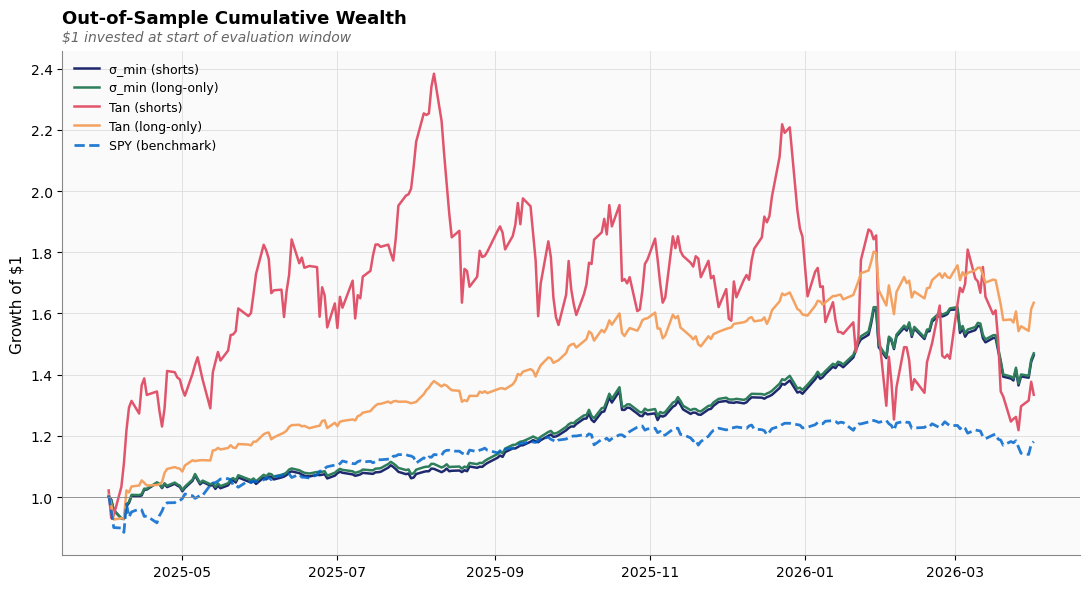

In [23]:
# --- Cumulative wealth on the evaluation window only ---
# Shows what each portfolio actually earned during the OOS period.

PORT_COLORS = {
    'σ_min (shorts)':    '#1F2A6E',
    'σ_min (long-only)': '#2E7D5B',
    'Tan (shorts)':      '#E1556C',
    'Tan (long-only)':   '#F4A261',
}

eval_wealth = pd.DataFrame({
    'σ_min (shorts)':    (1 + returns_eval[ASSETS] @ w_gmv_short_est).cumprod(),
    'σ_min (long-only)': (1 + returns_eval[ASSETS] @ w_gmv_long_est).cumprod(),
    'Tan (shorts)':      (1 + returns_eval[ASSETS] @ w_tan_short_est).cumprod(),
    'Tan (long-only)':   (1 + returns_eval[ASSETS] @ w_tan_long_est).cumprod(),
})
spy_eval_wealth = (1 + returns_eval['SPY']).cumprod()

fig, ax = plt.subplots(figsize=(11, 6))

for col in eval_wealth.columns:
    ax.plot(eval_wealth.index, eval_wealth[col],
            label=col, color=PORT_COLORS[col], lw=1.8)
ax.plot(spy_eval_wealth.index, spy_eval_wealth, label='SPY (benchmark)',
        color='#0066CC', lw=2, linestyle='--', alpha=0.85)
ax.axhline(1, color='#888888', lw=0.6)

ax.set_title('Out-of-Sample Cumulative Wealth', fontsize=13, fontweight='bold', loc='left', pad=20)
ax.text(0.0, 1.02, '$1 invested at start of evaluation window', transform=ax.transAxes,
        fontsize=10, style='italic', color='#666666')
ax.set_ylabel('Growth of $1', fontsize=11)
ax.legend(loc='upper left', fontsize=9, frameon=False)
plt.tight_layout()
plt.show()